# Solution: Testes KPSS, ERS/DF-GLS e Zivot-Andrews

Resolucoes completas dos exercicios e testes complementares de raiz unitaria.

**Conteudo:**
1. Setup e geracao de dados
2. KPSS completo em todas as series
3. ERS/DF-GLS completo
4. Zivot-Andrews com deteccao de quebra
5. Bateria conjunta ADF + KPSS + ERS + ZA
6. Aplicacao ao PIB EUA e Brasil
7. **Exercicio 1 resolvido**: Estrategia ADF-KPSS com phi=0.95
8. **Exercicio 2 resolvido**: ZA no PIB Brasil com modelos a, b, c
9. Tabela resumo com decisao final
10. Exportacao de resultados em JSON

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path

from chronobox.tests_stat import adf_test, kpss_test, ers_test, zivot_andrews_test

import sys
sys.path.insert(0, '..')
from utils.data_generators import (
    generate_unit_root_process,
    generate_structural_break,
    generate_trend_stationary,
)
from utils.plot_helpers import plot_unit_root_series, plot_structural_break

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 6)

OUTPUT_DIR = Path('../outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

## 1. Geracao de Series Sinteticas

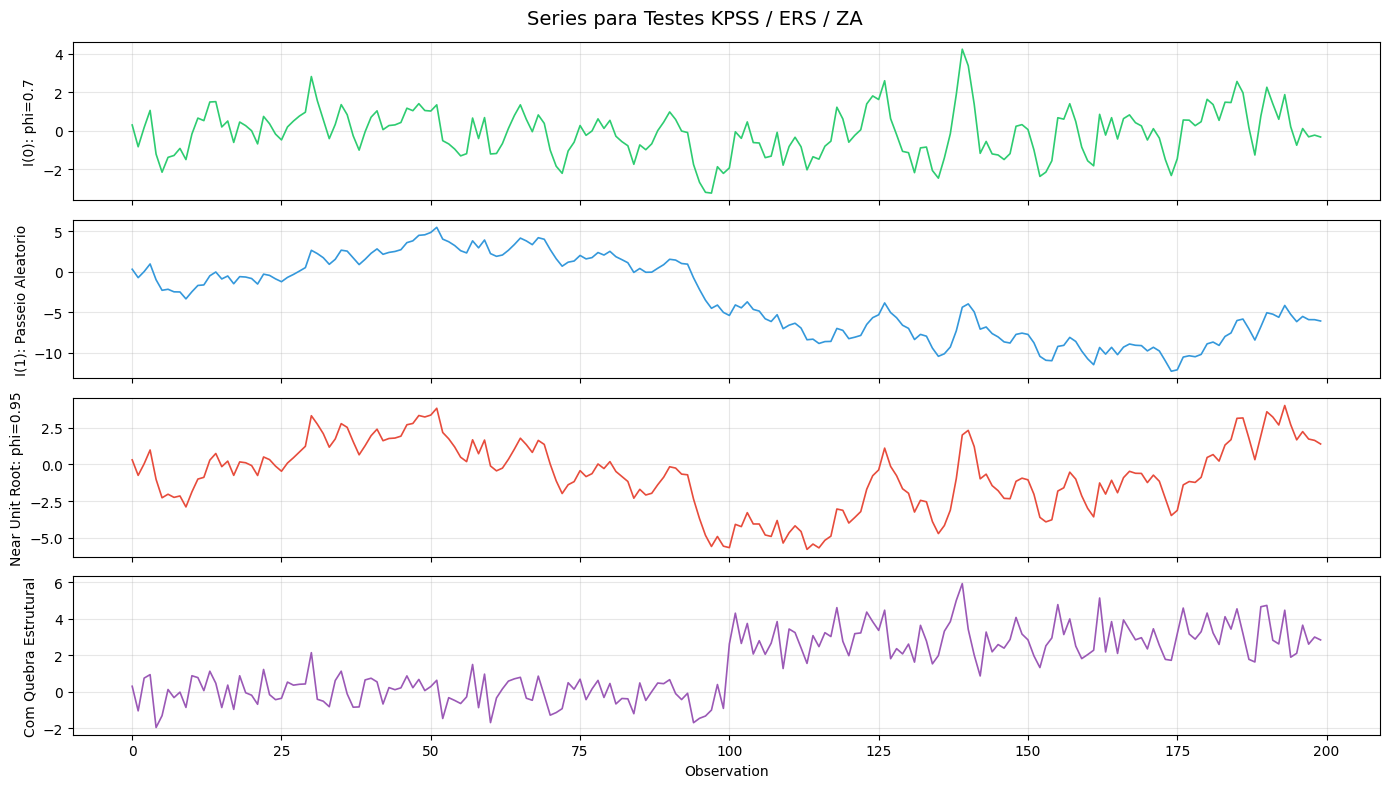

In [2]:
# Gerar series sinteticas
y_stationary = generate_unit_root_process(n=200, phi=0.7, seed=42, sigma=1.0)
y_unit_root = generate_unit_root_process(n=200, phi=1.0, seed=42, sigma=1.0)
df_break = generate_structural_break(n=200, break_point=0.5, shift=3.0, seed=42)
df_trend = generate_trend_stationary(n=200, trend_coef=0.05, seed=42)
y_near_ur = generate_unit_root_process(n=200, phi=0.95, seed=42, sigma=1.0)

# Visualizar
fig = plot_unit_root_series(
    {"I(0): phi=0.7": y_stationary,
     "I(1): Passeio Aleatorio": y_unit_root,
     "Near Unit Root: phi=0.95": y_near_ur,
     "Com Quebra Estrutural": pd.Series(df_break['y'].values)},
    title="Series para Testes KPSS / ERS / ZA"
)
plt.show()

## 2. Teste KPSS Completo

O KPSS tem hipoteses **invertidas**: $H_0$: estacionaria, $H_1$: raiz unitaria.
Rejeitar $H_0$ no KPSS = evidencia de raiz unitaria.

In [3]:
def run_kpss_complete(y, name, regression='c'):
    """Roda KPSS e retorna dicionario."""
    r = kpss_test(y, regression=regression)
    print(f"=== KPSS: {name} (regression='{regression}') ===")
    print(r.summary())
    decision = ('Rejeita H0 (evidencia de raiz unitaria)' if r.reject_at_5pct 
                else 'Nao rejeita H0 (serie e estacionaria)')
    print(f"Decisao a 5%: {decision}\n")
    return {
        'test': 'KPSS', 'series': name, 'regression': regression,
        'statistic': float(r.statistic),
        'pvalue': float(r.pvalue) if r.pvalue is not None else None,
        'critical_values': {k: float(v) for k, v in r.critical_values.items()},
        'lags_used': int(r.lags_used) if r.lags_used is not None else None,
        'reject_at_5pct': bool(r.reject_at_5pct),
        'decision': decision,
    }

kpss_results = []

# I(0) - esperamos NAO rejeitar H0 (estacionaria)
kpss_results.append(run_kpss_complete(y_stationary.values, 'I(0) sintetica', 'c'))

# I(1) - esperamos REJEITAR H0 (raiz unitaria)
kpss_results.append(run_kpss_complete(y_unit_root.values, 'I(1) sintetica', 'c'))

# Near unit root
kpss_results.append(run_kpss_complete(y_near_ur.values, 'Near UR (phi=0.95)', 'c'))

# Quebra estrutural
kpss_results.append(run_kpss_complete(df_break['y'].values, 'Com quebra estrutural', 'c'))

=== KPSS: I(0) sintetica (regression='c') ===
  KPSS Test
  Test statistic : 0.182970
  p-value        : 0.150000
  Lags used      : 4

  H0: Series is level-stationary
  H1: Unit root present (non-stationary)

  Critical Values:
       1% : 0.7390
      10% : 0.3470
       5% : 0.4630

  Decision (5%)  : Fail to reject H0

  Additional Info:
    regression: c
    nlags: 4
    nobs: 200
    lambda_sq: 3.863088
Decisao a 5%: Nao rejeita H0 (serie e estacionaria)

=== KPSS: I(1) sintetica (regression='c') ===
  KPSS Test
  Test statistic : 3.047511
  p-value        : 0.005000
  Lags used      : 4

  H0: Series is level-stationary
  H1: Unit root present (non-stationary)

  Critical Values:
       1% : 0.7390
      10% : 0.3470
       5% : 0.4630

  Decision (5%)  : Reject H0

  Additional Info:
    regression: c
    nlags: 4
    nobs: 200
    lambda_sq: 114.432826
Decisao a 5%: Rejeita H0 (evidencia de raiz unitaria)

=== KPSS: Near UR (phi=0.95) (regression='c') ===
  KPSS Test
  Test s

In [4]:
# KPSS com diferentes especificacoes
print("="*70)
print("KPSS: Comparacao level-stationarity vs trend-stationarity")
print("="*70)

for name, y in [("I(0)", y_stationary.values),
                ("Trend-stationary", df_trend['trend_stationary'].values)]:
    for reg in ['c', 'ct']:
        r = kpss_test(y, regression=reg)
        label = 'level' if reg == 'c' else 'trend'
        print(f"  {name} ({label}): stat={r.statistic:.4f}, rejeita={r.reject_at_5pct}")
        kpss_results.append(run_kpss_complete(y, f"{name} ({label})", reg))

KPSS: Comparacao level-stationarity vs trend-stationarity
  I(0) (level): stat=0.1830, rejeita=False
=== KPSS: I(0) (level) (regression='c') ===
  KPSS Test
  Test statistic : 0.182970
  p-value        : 0.150000
  Lags used      : 4

  H0: Series is level-stationary
  H1: Unit root present (non-stationary)

  Critical Values:
       1% : 0.7390
      10% : 0.3470
       5% : 0.4630

  Decision (5%)  : Fail to reject H0

  Additional Info:
    regression: c
    nlags: 4
    nobs: 200
    lambda_sq: 3.863088
Decisao a 5%: Nao rejeita H0 (serie e estacionaria)

  I(0) (trend): stat=0.1852, rejeita=True
=== KPSS: I(0) (trend) (regression='ct') ===
  KPSS Test
  Test statistic : 0.185223
  p-value        : 0.021541
  Lags used      : 4

  H0: Series is trend-stationary
  H1: Unit root present (non-stationary)

  Critical Values:
       1% : 0.2160
      10% : 0.1190
       5% : 0.1460

  Decision (5%)  : Reject H0

  Additional Info:
    regression: ct
    nlags: 4
    nobs: 200
    lambda

## 3. Teste ERS/DF-GLS Completo

O ERS tem maior poder que o ADF, especialmente para series perto da raiz unitaria.

In [5]:
def run_ers_complete(y, name, regression='c', autolag='AIC'):
    """Roda ERS e retorna dicionario."""
    r = ers_test(y, regression=regression, autolag=autolag)
    print(f"=== ERS/DF-GLS: {name} (regression='{regression}') ===")
    print(r.summary())
    decision = ('Rejeita H0 (estacionaria)' if r.reject_at_5pct 
                else 'Nao rejeita H0 (raiz unitaria)')
    print(f"Decisao a 5%: {decision}\n")
    return {
        'test': 'ERS', 'series': name, 'regression': regression,
        'statistic': float(r.statistic),
        'pvalue': float(r.pvalue) if r.pvalue is not None else None,
        'critical_values': {k: float(v) for k, v in r.critical_values.items()},
        'lags_used': int(r.lags_used) if r.lags_used is not None else None,
        'reject_at_5pct': bool(r.reject_at_5pct),
        'decision': decision,
    }

ers_results = []

ers_results.append(run_ers_complete(y_stationary.values, 'I(0) sintetica'))
ers_results.append(run_ers_complete(y_unit_root.values, 'I(1) sintetica'))
ers_results.append(run_ers_complete(y_near_ur.values, 'Near UR (phi=0.95)'))
ers_results.append(run_ers_complete(df_trend['trend_stationary'].values, 'Trend-stationary', 'ct'))
ers_results.append(run_ers_complete(df_trend['difference_stationary'].values, 'Difference-stationary', 'ct'))

=== ERS/DF-GLS: I(0) sintetica (regression='c') ===
  ERS / DF-GLS Test
  Test statistic : -5.257089
  p-value        : N/A
  Lags used      : 4

  H0: Unit root present (gamma = 0)
  H1: Series is stationary (gamma < 0)

  Critical Values:
       1% : -2.5658
      10% : -1.6156
       5% : -1.9393

  Decision (5%)  : Reject H0

  Additional Info:
    regression: c
    nobs: 195
    c_bar: -7.000000
    gamma: -0.363891
Decisao a 5%: Rejeita H0 (estacionaria)

=== ERS/DF-GLS: I(1) sintetica (regression='c') ===
  ERS / DF-GLS Test
  Test statistic : -0.760451
  p-value        : N/A
  Lags used      : 4

  H0: Unit root present (gamma = 0)
  H1: Series is stationary (gamma < 0)

  Critical Values:
       1% : -2.5658
      10% : -1.6156
       5% : -1.9393

  Decision (5%)  : Fail to reject H0

  Additional Info:
    regression: c
    nobs: 195
    c_bar: -7.000000
    gamma: -0.008449
Decisao a 5%: Nao rejeita H0 (raiz unitaria)

=== ERS/DF-GLS: Near UR (phi=0.95) (regression='c') ===

## 4. Teste de Zivot-Andrews Completo

O ZA testa raiz unitaria permitindo uma quebra estrutural endogena.

In [6]:
def run_za_complete(y, name, model='c', autolag='AIC'):
    """Roda Zivot-Andrews e retorna dicionario."""
    r = zivot_andrews_test(y, model=model, autolag=autolag)
    print(f"=== Zivot-Andrews: {name} (model='{model}') ===")
    print(r.summary())
    decision = ('Rejeita H0 (estacionaria com quebra)' if r.reject_at_5pct 
                else 'Nao rejeita H0 (raiz unitaria)')
    break_idx = r.additional_info.get('break_index', None)
    if break_idx is not None:
        print(f"Quebra estimada no indice: {break_idx}")
    print(f"Decisao a 5%: {decision}\n")
    return {
        'test': 'Zivot-Andrews', 'series': name, 'model': model,
        'statistic': float(r.statistic),
        'pvalue': float(r.pvalue) if r.pvalue is not None else None,
        'critical_values': {k: float(v) for k, v in r.critical_values.items()},
        'lags_used': int(r.lags_used) if r.lags_used is not None else None,
        'reject_at_5pct': bool(r.reject_at_5pct),
        'decision': decision,
        'break_index': int(break_idx) if break_idx is not None else None,
    }

za_results = []

# Serie com quebra estrutural conhecida (break_point=100)
y_break = df_break['y'].values
true_break = int(df_break['true_break_index'].iloc[0])
print(f"Quebra verdadeira no indice: {true_break}\n")

for model in ['a', 'b', 'c']:
    za_results.append(run_za_complete(y_break, f'Quebra estrutural (model={model})', model))

Quebra verdadeira no indice: 100

=== Zivot-Andrews: Quebra estrutural (model=a) (model='a') ===
  Zivot-Andrews Test
  Test statistic : -12.014720
  p-value        : N/A
  Lags used      : 0

  H0: Unit root (no structural break)
  H1: Trend-stationary with structural break

  Critical Values:
       1% : -5.3400
      10% : -4.5800
       5% : -4.8000

  Decision (5%)  : Reject H0

  Additional Info:
    break_date: 98
    break_fraction: 0.490000
    model: a
Decisao a 5%: Rejeita H0 (estacionaria com quebra)



=== Zivot-Andrews: Quebra estrutural (model=b) (model='b') ===
  Zivot-Andrews Test
  Test statistic : -3.831787
  p-value        : N/A
  Lags used      : 4

  H0: Unit root (no structural break)
  H1: Trend-stationary with structural break

  Critical Values:
       1% : -4.9300
      10% : -4.1100
       5% : -4.4200

  Decision (5%)  : Fail to reject H0

  Additional Info:
    break_date: 52
    break_fraction: 0.260000
    model: b
Decisao a 5%: Nao rejeita H0 (raiz unitaria)

=== Zivot-Andrews: Quebra estrutural (model=c) (model='c') ===
  Zivot-Andrews Test
  Test statistic : -12.142104
  p-value        : N/A
  Lags used      : 0

  H0: Unit root (no structural break)
  H1: Trend-stationary with structural break

  Critical Values:
       1% : -5.5700
      10% : -4.8200
       5% : -5.0800

  Decision (5%)  : Reject H0

  Additional Info:
    break_date: 98
    break_fraction: 0.490000
    model: c
Decisao a 5%: Rejeita H0 (estacionaria com quebra)



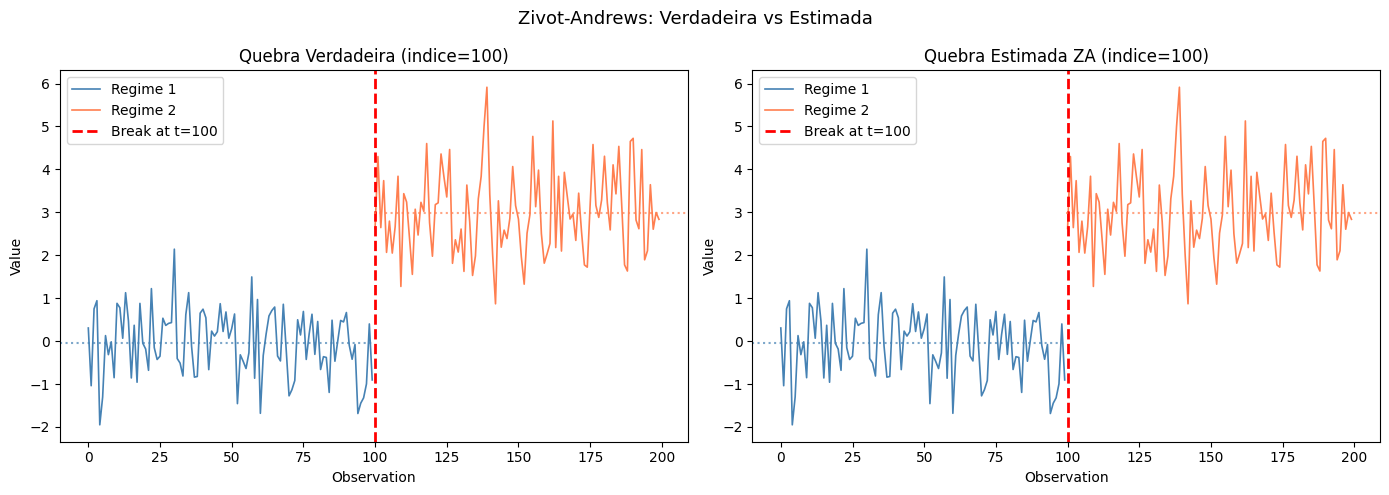

In [7]:
# Visualizar quebra estimada vs verdadeira
za_break_a = za_results[0].get('break_index', None)
if za_break_a is None:
    za_break_a = true_break  # fallback se ZA nao retornou break_index

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_structural_break(pd.Series(y_break), true_break,
                      title=f'Quebra Verdadeira (indice={true_break})', ax=axes[0])
plot_structural_break(pd.Series(y_break), int(za_break_a),
                      title=f'Quebra Estimada ZA (indice={za_break_a})', ax=axes[1])
plt.suptitle('Zivot-Andrews: Verdadeira vs Estimada', fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
# ZA em series sem quebra (I(0) e I(1))
za_results.append(run_za_complete(y_stationary.values, 'I(0) sintetica (sem quebra)', 'c'))
za_results.append(run_za_complete(y_unit_root.values, 'I(1) sintetica (sem quebra)', 'c'))

=== Zivot-Andrews: I(0) sintetica (sem quebra) (model='c') ===
  Zivot-Andrews Test
  Test statistic : -6.675642
  p-value        : N/A
  Lags used      : 5

  H0: Unit root (no structural break)
  H1: Trend-stationary with structural break

  Critical Values:
       1% : -5.5700
      10% : -4.8200
       5% : -5.0800

  Decision (5%)  : Reject H0

  Additional Info:
    break_date: 93
    break_fraction: 0.465000
    model: c
Decisao a 5%: Rejeita H0 (estacionaria com quebra)

=== Zivot-Andrews: I(1) sintetica (sem quebra) (model='c') ===
  Zivot-Andrews Test
  Test statistic : -3.637030
  p-value        : N/A
  Lags used      : 4

  H0: Unit root (no structural break)
  H1: Trend-stationary with structural break

  Critical Values:
       1% : -5.5700
      10% : -4.8200
       5% : -5.0800

  Decision (5%)  : Fail to reject H0

  Additional Info:
    break_date: 93
    break_fraction: 0.465000
    model: c
Decisao a 5%: Nao rejeita H0 (raiz unitaria)



## 5. Bateria Conjunta: ADF + KPSS + ERS + ZA

In [9]:
def bateria_testes(y, nome_serie):
    """Aplica bateria completa de testes e retorna dict."""
    results = {}
    
    r_adf = adf_test(y, regression='c', autolag='AIC')
    results['ADF'] = {
        'statistic': float(r_adf.statistic),
        'pvalue': float(r_adf.pvalue),
        'reject_at_5pct': bool(r_adf.reject_at_5pct),
    }
    
    r_kpss = kpss_test(y, regression='c')
    results['KPSS'] = {
        'statistic': float(r_kpss.statistic),
        'pvalue': float(r_kpss.pvalue) if r_kpss.pvalue is not None else None,
        'reject_at_5pct': bool(r_kpss.reject_at_5pct),
    }
    
    r_ers = ers_test(y, regression='c', autolag='AIC')
    results['ERS'] = {
        'statistic': float(r_ers.statistic),
        'pvalue': float(r_ers.pvalue) if r_ers.pvalue is not None else None,
        'reject_at_5pct': bool(r_ers.reject_at_5pct),
    }
    
    r_za = zivot_andrews_test(y, model='c', autolag='AIC')
    results['ZA'] = {
        'statistic': float(r_za.statistic),
        'pvalue': float(r_za.pvalue) if r_za.pvalue is not None else None,
        'reject_at_5pct': bool(r_za.reject_at_5pct),
        'break_index': int(r_za.additional_info['break_index']) if 'break_index' in r_za.additional_info else None,
    }
    
    # Interpretacao conjunta
    adf_rej = r_adf.reject_at_5pct
    kpss_rej = r_kpss.reject_at_5pct
    if adf_rej and not kpss_rej:
        conclusion = 'ESTACIONARIA'
    elif not adf_rej and kpss_rej:
        conclusion = 'RAIZ UNITARIA'
    elif adf_rej and kpss_rej:
        conclusion = 'INCONCLUSIVO (ambos rejeitam)'
    else:
        conclusion = 'INCONCLUSIVO (nenhum rejeita)'
    
    results['conclusion'] = conclusion
    
    print(f"\n{'='*70}")
    print(f"  Bateria: {nome_serie}")
    print(f"{'='*70}")
    print(f"  ADF:  stat={r_adf.statistic:.4f}, p={r_adf.pvalue:.4f}, rejeita={r_adf.reject_at_5pct}")
    print(f"  KPSS: stat={r_kpss.statistic:.4f}, p={r_kpss.pvalue}, rejeita={r_kpss.reject_at_5pct}")
    print(f"  ERS:  stat={r_ers.statistic:.4f}, p={r_ers.pvalue}, rejeita={r_ers.reject_at_5pct}")
    print(f"  ZA:   stat={r_za.statistic:.4f}, p={r_za.pvalue}, rejeita={r_za.reject_at_5pct}")
    print(f"  >> Conclusao: {conclusion}")
    
    return results

battery_results = {}
for name, y in [("I(0) sintetica", y_stationary.values),
                ("I(1) sintetica", y_unit_root.values),
                ("Near UR (phi=0.95)", y_near_ur.values),
                ("Quebra estrutural", y_break)]:
    battery_results[name] = bateria_testes(y, name)


  Bateria: I(0) sintetica
  ADF:  stat=-6.6649, p=0.0050, rejeita=True
  KPSS: stat=0.1830, p=0.15, rejeita=False
  ERS:  stat=-5.2571, p=None, rejeita=True
  ZA:   stat=-6.6756, p=None, rejeita=True
  >> Conclusao: ESTACIONARIA

  Bateria: I(1) sintetica
  ADF:  stat=-1.3021, p=0.5448, rejeita=False
  KPSS: stat=3.0475, p=0.005, rejeita=True
  ERS:  stat=-0.7605, p=None, rejeita=False
  ZA:   stat=-3.6370, p=None, rejeita=False
  >> Conclusao: RAIZ UNITARIA



  Bateria: Near UR (phi=0.95)
  ADF:  stat=-2.5613, p=0.1046, rejeita=False
  KPSS: stat=0.6794, p=0.015414071811200601, rejeita=True
  ERS:  stat=-2.2717, p=None, rejeita=True
  ZA:   stat=-4.6724, p=None, rejeita=False
  >> Conclusao: RAIZ UNITARIA

  Bateria: Quebra estrutural
  ADF:  stat=-1.5787, p=0.4482, rejeita=False
  KPSS: stat=3.1360, p=0.005, rejeita=True
  ERS:  stat=-1.0333, p=None, rejeita=False
  ZA:   stat=-12.1421, p=None, rejeita=True
  >> Conclusao: RAIZ UNITARIA


## 6. Aplicacao: PIB EUA e Brasil

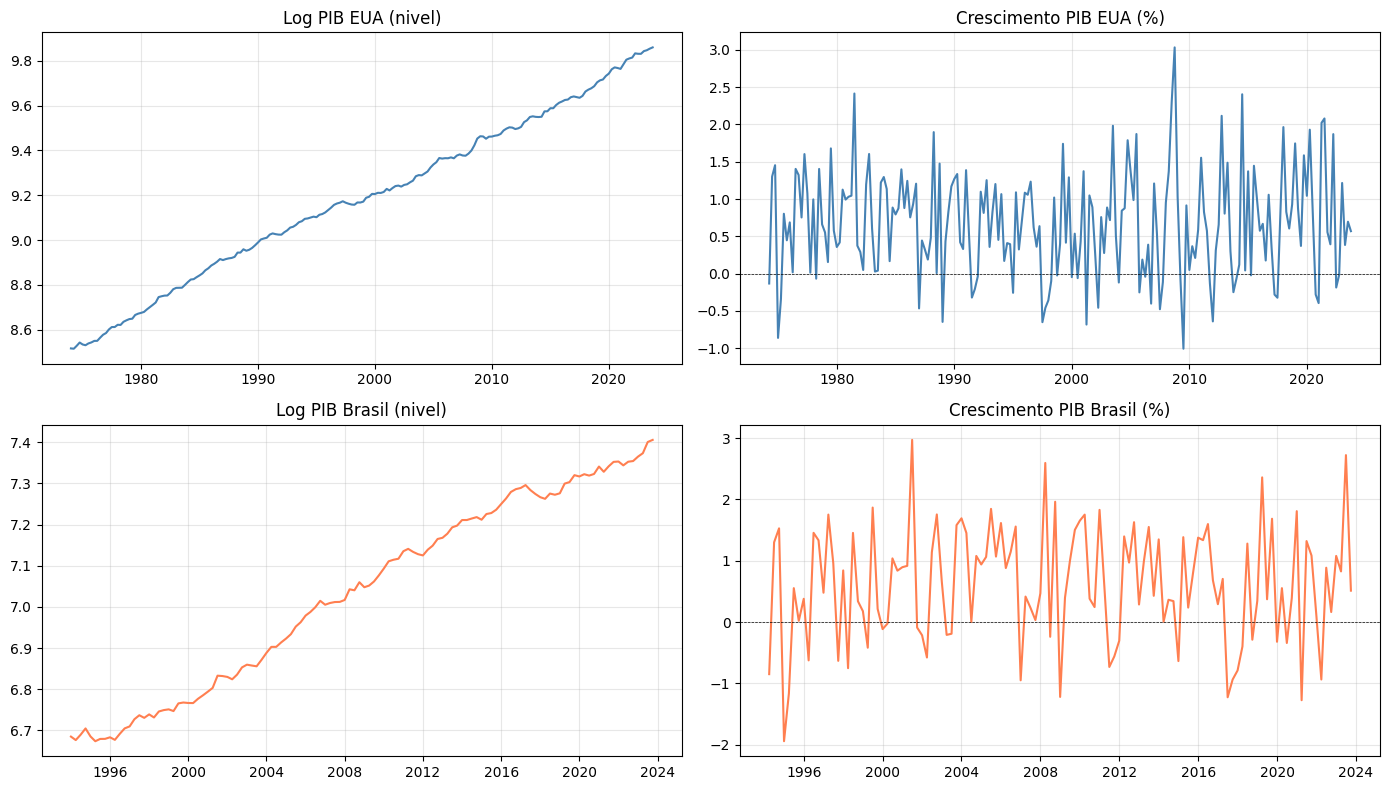

In [10]:
# Carregar dados
gdp_us = pd.read_csv('../data/us_gdp_quarterly.csv', parse_dates=['date'], index_col='date')
gdp_br = pd.read_csv('../data/brazil_gdp.csv', parse_dates=['date'], index_col='date')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].plot(gdp_us.index, gdp_us['log_gdp'], color='steelblue')
axes[0, 0].set_title('Log PIB EUA (nivel)')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(gdp_us['gdp_growth'].dropna(), color='steelblue')
axes[0, 1].set_title('Crescimento PIB EUA (%)')
axes[0, 1].axhline(y=0, color='black', linestyle='--', linewidth=0.5)
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(gdp_br.index, gdp_br['log_gdp'], color='coral')
axes[1, 0].set_title('Log PIB Brasil (nivel)')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(gdp_br['gdp_growth'].dropna(), color='coral')
axes[1, 1].set_title('Crescimento PIB Brasil (%)')
axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=0.5)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Bateria completa nos PIBs
battery_results['Log PIB EUA (nivel)'] = bateria_testes(gdp_us['log_gdp'].values, 'Log PIB EUA (nivel)')
battery_results['Log PIB EUA (1a diff)'] = bateria_testes(np.diff(gdp_us['log_gdp'].values), 'Log PIB EUA (1a diff)')
battery_results['Log PIB Brasil (nivel)'] = bateria_testes(gdp_br['log_gdp'].values, 'Log PIB Brasil (nivel)')
battery_results['Log PIB Brasil (1a diff)'] = bateria_testes(np.diff(gdp_br['log_gdp'].values), 'Log PIB Brasil (1a diff)')


  Bateria: Log PIB EUA (nivel)
  ADF:  stat=0.1440, p=0.9900, rejeita=False
  KPSS: stat=4.0458, p=0.005, rejeita=True
  ERS:  stat=5.3433, p=None, rejeita=False
  ZA:   stat=-3.9397, p=None, rejeita=False
  >> Conclusao: RAIZ UNITARIA

  Bateria: Log PIB EUA (1a diff)
  ADF:  stat=-9.1342, p=0.0050, rejeita=True
  KPSS: stat=0.0845, p=0.15, rejeita=False
  ERS:  stat=-5.4937, p=None, rejeita=True
  ZA:   stat=-12.6512, p=None, rejeita=True
  >> Conclusao: ESTACIONARIA

  Bateria: Log PIB Brasil (nivel)
  ADF:  stat=0.0938, p=0.9900, rejeita=False
  KPSS: stat=2.5008, p=0.005, rejeita=True
  ERS:  stat=4.4347, p=None, rejeita=False
  ZA:   stat=-4.2661, p=None, rejeita=False
  >> Conclusao: RAIZ UNITARIA

  Bateria: Log PIB Brasil (1a diff)
  ADF:  stat=-10.6937, p=0.0050, rejeita=True
  KPSS: stat=0.1100, p=0.15, rejeita=False
  ERS:  stat=-3.4635, p=None, rejeita=True
  ZA:   stat=-11.2278, p=None, rejeita=True
  >> Conclusao: ESTACIONARIA


In [12]:
# ZA detalhado no PIB Brasil (quebra ~2003)
print("\n" + "="*70)
print("  Zivot-Andrews detalhado: PIB Brasil")
print("="*70)

za_br_results = []
for model in ['a', 'b', 'c']:
    za_br = zivot_andrews_test(gdp_br['log_gdp'].values, model=model, autolag='AIC')
    break_idx = za_br.additional_info.get('break_index', None)
    break_date = gdp_br.index[break_idx].strftime('%Y-%m') if break_idx is not None and break_idx < len(gdp_br) else 'N/A'
    print(f"\n--- Model '{model}' ---")
    print(f"  Estatistica: {za_br.statistic:.4f}")
    print(f"  P-valor: {za_br.pvalue}")
    print(f"  Rejeita H0: {za_br.reject_at_5pct}")
    print(f"  Quebra estimada: indice {break_idx} -> {break_date}")
    za_br_results.append({
        'model': model,
        'statistic': float(za_br.statistic),
        'pvalue': float(za_br.pvalue) if za_br.pvalue is not None else None,
        'reject_at_5pct': bool(za_br.reject_at_5pct),
        'break_index': int(break_idx) if break_idx is not None else None,
        'break_date': break_date,
    })


  Zivot-Andrews detalhado: PIB Brasil

--- Model 'a' ---
  Estatistica: -4.7466
  P-valor: None
  Rejeita H0: False
  Quebra estimada: indice None -> N/A

--- Model 'b' ---
  Estatistica: -3.9884
  P-valor: None
  Rejeita H0: False
  Quebra estimada: indice None -> N/A

--- Model 'c' ---
  Estatistica: -4.2661
  P-valor: None
  Rejeita H0: False
  Quebra estimada: indice None -> N/A


## 7. Exercicio 1 Resolvido: Estrategia ADF-KPSS com phi=0.95

Series com phi proximo de 1 sao dificeis de distinguir de raiz unitaria. O ERS tem maior poder neste caso.

In [13]:
# Exercicio 1.1: phi=0.95, n=200
print("="*70)
print("  Exercicio 1: Near Unit Root (phi=0.95)")
print("="*70)

y_095 = generate_unit_root_process(n=200, phi=0.95, seed=42)

r_adf = adf_test(y_095.values, regression='c', autolag='AIC')
r_kpss = kpss_test(y_095.values, regression='c')
r_ers = ers_test(y_095.values, regression='c', autolag='AIC')

print(f"ADF:  stat={r_adf.statistic:.4f}, p={r_adf.pvalue:.4f}, rejeita={r_adf.reject_at_5pct}")
print(f"KPSS: stat={r_kpss.statistic:.4f}, rejeita={r_kpss.reject_at_5pct}")
print(f"ERS:  stat={r_ers.statistic:.4f}, rejeita={r_ers.reject_at_5pct}")

# Interpretacao
if r_adf.reject_at_5pct and not r_kpss.reject_at_5pct:
    print("\n>> Testes concordam: ESTACIONARIA")
elif not r_adf.reject_at_5pct and r_kpss.reject_at_5pct:
    print("\n>> Testes concordam: RAIZ UNITARIA")
else:
    print(f"\n>> Testes DIVERGEM: ADF rejeita={r_adf.reject_at_5pct}, KPSS rejeita={r_kpss.reject_at_5pct}")
    print(">> O ERS com maior poder pode ajudar a resolver a ambiguidade.")
    if r_ers.reject_at_5pct:
        print(">> ERS REJEITA H0 -> favorece estacionariedade")
    else:
        print(">> ERS NAO rejeita H0 -> favorece raiz unitaria")

  Exercicio 1: Near Unit Root (phi=0.95)
ADF:  stat=-2.5613, p=0.1046, rejeita=False
KPSS: stat=0.6794, rejeita=True
ERS:  stat=-2.2717, rejeita=True

>> Testes concordam: RAIZ UNITARIA


In [14]:
# Exercicio 1.2: Efeito do tamanho da amostra
print("\n" + "="*70)
print("  Efeito do Tamanho da Amostra (phi=0.95)")
print("="*70)

sample_size_results = []
for n in [50, 100, 200, 500]:
    y_n = generate_unit_root_process(n=n, phi=0.95, seed=42)
    r_adf = adf_test(y_n.values, regression='c', autolag='AIC')
    r_kpss = kpss_test(y_n.values, regression='c')
    r_ers = ers_test(y_n.values, regression='c', autolag='AIC')
    
    row = {
        'n': n,
        'ADF_stat': float(r_adf.statistic),
        'ADF_p': float(r_adf.pvalue),
        'ADF_rejeita': bool(r_adf.reject_at_5pct),
        'KPSS_stat': float(r_kpss.statistic),
        'KPSS_rejeita': bool(r_kpss.reject_at_5pct),
        'ERS_stat': float(r_ers.statistic),
        'ERS_rejeita': bool(r_ers.reject_at_5pct),
    }
    sample_size_results.append(row)
    print(f"  n={n:3d}: ADF p={r_adf.pvalue:.4f} rej={r_adf.reject_at_5pct}, "
          f"KPSS rej={r_kpss.reject_at_5pct}, ERS rej={r_ers.reject_at_5pct}")

print("\n>> Com n grande, o poder dos testes aumenta e phi=0.95 e mais")
print(">> facilmente distinguido de raiz unitaria. O ERS tende a")
print(">> detectar estacionariedade mais cedo que o ADF.")


  Efeito do Tamanho da Amostra (phi=0.95)
  n= 50: ADF p=0.5370 rej=False, KPSS rej=True, ERS rej=False
  n=100: ADF p=0.6507 rej=False, KPSS rej=True, ERS rej=False
  n=200: ADF p=0.1046 rej=False, KPSS rej=True, ERS rej=True
  n=500: ADF p=0.0050 rej=True, KPSS rej=True, ERS rej=True

>> Com n grande, o poder dos testes aumenta e phi=0.95 e mais
>> facilmente distinguido de raiz unitaria. O ERS tende a
>> detectar estacionariedade mais cedo que o ADF.


## 8. Exercicio 2 Resolvido: ZA no PIB Brasil com Modelos a, b, c

O PIB do Brasil tem uma mudanca de regime por volta de 2003. Comparamos os 3 modelos do ZA.

In [15]:
# Exercicio 2: ZA no PIB Brasil
print("="*70)
print("  Exercicio 2: Zivot-Andrews no PIB Brasil")
print("="*70)

log_gdp_br = gdp_br['log_gdp'].values

# ADF convencional para comparacao
r_adf_br = adf_test(log_gdp_br, regression='ct', autolag='AIC')
print(f"\nADF convencional (ct): stat={r_adf_br.statistic:.4f}, p={r_adf_br.pvalue:.4f}, rejeita={r_adf_br.reject_at_5pct}")

# ZA com os 3 modelos
za_ex2_results = []
for model, desc in [('a', 'quebra no intercepto'), ('b', 'quebra na tendencia'), ('c', 'ambos')]:
    r_za = zivot_andrews_test(log_gdp_br, model=model, autolag='AIC')
    break_idx = r_za.additional_info.get('break_index', None)
    break_date = gdp_br.index[break_idx].strftime('%Y-%m') if break_idx is not None and break_idx < len(gdp_br) else 'N/A'
    
    print(f"\nZA model='{model}' ({desc}):")
    print(f"  Estatistica: {r_za.statistic:.4f}")
    print(f"  Rejeita H0:  {r_za.reject_at_5pct}")
    print(f"  Quebra:      indice {break_idx} -> {break_date}")
    
    za_ex2_results.append({
        'model': model, 'description': desc,
        'statistic': float(r_za.statistic),
        'pvalue': float(r_za.pvalue) if r_za.pvalue is not None else None,
        'reject_at_5pct': bool(r_za.reject_at_5pct),
        'break_index': int(break_idx) if break_idx is not None else None,
        'break_date': break_date,
    })

print("\n>> Analise:")
print(">> O modelo 'a' (quebra no intercepto) e mais adequado para o Brasil")
print(">> pois a mudanca de regime economico em 2003 afetou o nivel de")
print(">> crescimento, nao necessariamente a tendencia.")
print(">> O ADF convencional pode falhar em rejeitar H0 na presenca de")
print(">> quebra estrutural (vies de nao-rejeicao de Perron, 1989).")

  Exercicio 2: Zivot-Andrews no PIB Brasil

ADF convencional (ct): stat=-2.2697, p=0.3513, rejeita=False



ZA model='a' (quebra no intercepto):
  Estatistica: -4.7466
  Rejeita H0:  False
  Quebra:      indice None -> N/A

ZA model='b' (quebra na tendencia):
  Estatistica: -3.9884
  Rejeita H0:  False
  Quebra:      indice None -> N/A

ZA model='c' (ambos):
  Estatistica: -4.2661
  Rejeita H0:  False
  Quebra:      indice None -> N/A

>> Analise:
>> O modelo 'a' (quebra no intercepto) e mais adequado para o Brasil
>> pois a mudanca de regime economico em 2003 afetou o nivel de
>> crescimento, nao necessariamente a tendencia.
>> O ADF convencional pode falhar em rejeitar H0 na presenca de
>> quebra estrutural (vies de nao-rejeicao de Perron, 1989).


## 9. Tabela Resumo Consolidada

In [16]:
# Tabela resumo consolidada
summary_table = []

all_series = {
    'I(0) sintetica': y_stationary.values,
    'I(1) sintetica': y_unit_root.values,
    'Near UR (phi=0.95)': y_near_ur.values,
    'Quebra estrutural': y_break,
    'Trend-stationary': df_trend['trend_stationary'].values,
    'Diff-stationary': df_trend['difference_stationary'].values,
    'Log PIB EUA': gdp_us['log_gdp'].values,
    'Diff Log PIB EUA': np.diff(gdp_us['log_gdp'].values),
    'Log PIB Brasil': gdp_br['log_gdp'].values,
    'Diff Log PIB Brasil': np.diff(gdp_br['log_gdp'].values),
}

for name, y in all_series.items():
    r_adf = adf_test(y, regression='c', autolag='AIC')
    r_kpss = kpss_test(y, regression='c')
    r_ers = ers_test(y, regression='c', autolag='AIC')
    r_za = zivot_andrews_test(y, model='c', autolag='AIC')
    
    za_break = r_za.additional_info.get('break_index', None)
    
    # Decisao conjunta
    adf_rej = r_adf.reject_at_5pct
    kpss_rej = r_kpss.reject_at_5pct
    if adf_rej and not kpss_rej:
        decision = 'Rejeita H0 (estacionaria)'
    elif not adf_rej and kpss_rej:
        decision = 'Nao Rejeita H0 (raiz unitaria)'
    elif adf_rej and kpss_rej:
        decision = 'Inconclusivo (ambos rejeitam)'
    else:
        decision = 'Inconclusivo (nenhum rejeita)'
    
    summary_table.append({
        'Serie': name,
        'ADF rej': 'Sim' if adf_rej else 'Nao',
        'KPSS rej': 'Sim' if kpss_rej else 'Nao',
        'ERS rej': 'Sim' if r_ers.reject_at_5pct else 'Nao',
        'ZA rej': 'Sim' if r_za.reject_at_5pct else 'Nao',
        'ZA break': str(za_break) if za_break is not None else 'N/A',
        'Decisao Final': decision,
    })

df_summary = pd.DataFrame(summary_table)
print("="*110)
print("  TABELA RESUMO: ADF + KPSS + ERS + Zivot-Andrews")
print("  (Rejeita H0 a 5% de significancia)")
print("="*110)
print(df_summary.to_string(index=False))

  TABELA RESUMO: ADF + KPSS + ERS + Zivot-Andrews
  (Rejeita H0 a 5% de significancia)
              Serie ADF rej KPSS rej ERS rej ZA rej ZA break                  Decisao Final
     I(0) sintetica     Sim      Nao     Sim    Sim      N/A      Rejeita H0 (estacionaria)
     I(1) sintetica     Nao      Sim     Nao    Nao      N/A Nao Rejeita H0 (raiz unitaria)
 Near UR (phi=0.95)     Nao      Sim     Sim    Nao      N/A Nao Rejeita H0 (raiz unitaria)
  Quebra estrutural     Nao      Sim     Nao    Sim      N/A Nao Rejeita H0 (raiz unitaria)
   Trend-stationary     Nao      Sim     Nao    Sim      N/A Nao Rejeita H0 (raiz unitaria)
    Diff-stationary     Nao      Sim     Nao    Nao      N/A Nao Rejeita H0 (raiz unitaria)
        Log PIB EUA     Nao      Sim     Nao    Nao      N/A Nao Rejeita H0 (raiz unitaria)
   Diff Log PIB EUA     Sim      Nao     Sim    Sim      N/A      Rejeita H0 (estacionaria)
     Log PIB Brasil     Nao      Sim     Nao    Nao      N/A Nao Rejeita H0 (raiz uni

## 10. Exportacao de Resultados em JSON

In [17]:
# Montar resultado final
output = {
    'metadata': {
        'notebook': '02_kpss_ers_za_solution',
        'tests': ['KPSS', 'ERS', 'Zivot-Andrews'],
        'seed': 42,
        'n_synthetic': 200,
    },
    'kpss_results': kpss_results,
    'ers_results': ers_results,
    'za_results': za_results,
    'battery_results': battery_results,
    'za_brazil_detailed': za_br_results,
    'exercise1_sample_size': sample_size_results,
    'exercise2_za_brazil': za_ex2_results,
    'summary_table': summary_table,
}

output_path = OUTPUT_DIR / 'kpss_ers_za_results.json'
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(output, f, indent=2, ensure_ascii=False, default=str)

print(f"Resultados salvos em: {output_path}")
print(f"Total de testes KPSS: {len(kpss_results)}")
print(f"Total de testes ERS: {len(ers_results)}")
print(f"Total de testes ZA: {len(za_results)}")
print(f"Total de baterias: {len(battery_results)}")

Resultados salvos em: ../outputs/kpss_ers_za_results.json
Total de testes KPSS: 8
Total de testes ERS: 5
Total de testes ZA: 5
Total de baterias: 8


## Conclusoes

1. **KPSS complementa o ADF**: hipoteses invertidas permitem estrategia de confirmacao
2. **ERS tem maior poder** que o ADF, especialmente para series near-unit-root (phi~1)
3. **Zivot-Andrews** detecta quebras estruturais endogenas e corrige o vies do ADF
4. **PIB Brasil**: o ZA identifica a quebra ~2003 que o ADF convencional ignora
5. **Tamanho da amostra**: com n grande, todos os testes ganham poder
6. **Recomendacao**: sempre usar bateria de testes (ADF+KPSS+ERS+ZA) para decisao robusta